In [ ]:
pip install scipy

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import time


class FreezingSoilFDM:
    """
    1D finite difference model for freezing/thawing soil
    using apparent heat capacity method.
    """

    def __init__(self, params):
        # ---------------- Physical parameters ----------------
        self.L = params['L']                    # latent heat (MJ/m^3)
        self.C_i = params['C_i']
        self.C_l = params['C_l']
        self.C_f = params['C_f']
        self.lambda_i = params['lambda_i']
        self.lambda_l = params['lambda_l']
        self.lambda_f = params['lambda_f']
        self.eta = params['eta']
        self.b = params['b']
        self.T_nabla = params['T_nabla']

        # ---------------- Smoothing parameters ----------------
        self.k_phi = params.get('k_phi', 0.8)   # smaller -> smoother transition
        self.eps_phi = params.get('eps_phi', 1e-6)

        # ---------------- Grid parameters ----------------
        self.Nx = None
        self.Nt = None
        self.Lx = None
        self.T_total = None
        self.dx = None
        self.dt = None

        self.x = None
        self.t = None
        self.T_field = None

    # ============================================================
    # Boundary / initial conditions
    # ============================================================
    def boundary_temperature(self, t):
        return 4.03 + 16.11 * np.sin(2.0 * np.pi * t / 365.0 - 1.709)

    def initial_temperature_profile(self, x):
        T_surface = self.boundary_temperature(0.0)
        T_bottom = 1.0
        return T_surface + (T_bottom - T_surface) / 5.0 * x

    # ============================================================
    # Stable sigmoid
    # ============================================================
    def stable_sigmoid(self, z):
        z = np.asarray(z, dtype=float)
        z = np.clip(z, -60.0, 60.0)
        return 1.0 / (1.0 + np.exp(-z))

    # ============================================================
    # Constitutive relations
    # ============================================================
    def pore_water_content(self, T):
        """
        Smoothed liquid water fraction phi(T), constrained to [0, 1].
        """
        T = np.asarray(T, dtype=float)
        T_abs = np.clip(np.abs(T), self.eps_phi, None)

        phi_frozen = (abs(self.T_nabla) ** self.b) * (T_abs ** (-self.b))
        phi_frozen = np.minimum(phi_frozen, 1.0)

        z = self.k_phi * (T - self.T_nabla)
        step = self.stable_sigmoid(z)

        phi = step * 1.0 + (1.0 - step) * phi_frozen
        return np.clip(phi, 0.0, 1.0)

    def unfrozen_water_content(self, T):
        return self.eta * self.pore_water_content(T)

    def effective_heat_capacity(self, T):
        phi = self.pore_water_content(T)
        return (
            (1.0 - self.eta) * self.C_f
            + self.eta * (phi * self.C_l + (1.0 - phi) * self.C_i)
        )

    def effective_conductivity(self, T):
        phi = self.pore_water_content(T)
        return (
            (1.0 - self.eta) * self.lambda_f
            + self.eta * (phi * self.lambda_l + (1.0 - phi) * self.lambda_i)
        )

    def dtheta_dT(self, T):
        """
        Numerical derivative of unfrozen water content with respect to T.
        """
        h = 1e-4
        theta_plus = self.unfrozen_water_content(np.asarray(T) + h)
        theta_minus = self.unfrozen_water_content(np.asarray(T) - h)
        return (theta_plus - theta_minus) / (2.0 * h)

    def apparent_heat_capacity(self, T):
        """
        Apparent heat capacity:
            C_app = C_eff + L * |dtheta/dT|
        """
        C_eff = self.effective_heat_capacity(T)
        dtheta = self.dtheta_dT(T)
        C_app = C_eff + self.L * np.abs(dtheta)

        # avoid too small or pathological values
        C_app = np.maximum(C_app, 1e-6)
        return C_app

    @staticmethod
    def harmonic_mean(a, b, eps=1e-12):
        return 2.0 * a * b / (a + b + eps)

    # ============================================================
    # Initialization
    # ============================================================
    def initialize(self, Nx=101, Nt=15000, Lx=5.0, T_total=365.0 * 3):
        self.Nx = Nx
        self.Nt = Nt
        self.Lx = Lx
        self.T_total = T_total

        self.dx = Lx / (Nx - 1)
        self.dt = T_total / (Nt - 1)

        self.x = np.linspace(0.0, Lx, Nx)
        self.t = np.linspace(0.0, T_total, Nt)

        T_init = self.initial_temperature_profile(self.x)

        self.T_field = np.zeros((Nx, Nt), dtype=float)
        self.T_field[:, 0] = T_init

    # ============================================================
    # Diagnostics
    # ============================================================
    def print_diagnostics(self, T):
        phi = self.pore_water_content(T)
        Ceff = self.effective_heat_capacity(T)
        Capp = self.apparent_heat_capacity(T)
        lam = self.effective_conductivity(T)

        print("Diagnostics:")
        print(f"  T range      : [{np.min(T):.6f}, {np.max(T):.6f}]")
        print(f"  phi range    : [{np.min(phi):.6f}, {np.max(phi):.6f}]")
        print(f"  C_eff range  : [{np.min(Ceff):.6f}, {np.max(Ceff):.6f}]")
        print(f"  C_app range  : [{np.min(Capp):.6f}, {np.max(Capp):.6f}]")
        print(f"  lambda range : [{np.min(lam):.6f}, {np.max(lam):.6f}]")
        print(f"  dx = {self.dx:.6f}, dt = {self.dt:.6f}")

    # ============================================================
    # Implicit solver (apparent heat capacity)
    # ============================================================
    def solve_implicit(self, verbose=True):
        """
        Implicit FDM with apparent heat capacity method.
        """
        if self.T_field is None:
            raise RuntimeError("Please call initialize() first.")

        start = time.time()
        T = self.T_field[:, 0].copy()

        if verbose:
            print("Starting implicit FDM solver with apparent heat capacity...")
            self.print_diagnostics(T)

        for n in range(1, self.Nt):
            t_n = self.t[n]

            C_app = self.apparent_heat_capacity(T)
            lambda_eff = self.effective_conductivity(T)

            A = np.zeros((self.Nx, self.Nx), dtype=float)
            b = np.zeros(self.Nx, dtype=float)

            # boundary conditions
            A[0, 0] = 1.0
            b[0] = self.boundary_temperature(t_n)

            A[-1, -1] = 1.0
            b[-1] = 1.0

            for i in range(1, self.Nx - 1):
                lam_p = self.harmonic_mean(lambda_eff[i], lambda_eff[i + 1])
                lam_m = self.harmonic_mean(lambda_eff[i], lambda_eff[i - 1])

                alpha = self.dt / (C_app[i] * self.dx**2)

                A[i, i - 1] = -0.5 * alpha * lam_m
                A[i, i] = 1.0 + 0.5 * alpha * (lam_p + lam_m)
                A[i, i + 1] = -0.5 * alpha * lam_p

                conduction = 0.5 * alpha * (
                    lam_p * (T[i + 1] - T[i]) - lam_m * (T[i] - T[i - 1])
                )

                b[i] = T[i] + conduction

            T_new = np.linalg.solve(A, b)

            if np.any(np.isnan(T_new)) or np.any(np.isinf(T_new)):
                raise RuntimeError(f"NaN/Inf detected at time step {n}")

            self.T_field[:, n] = T_new
            T = T_new.copy()

            if verbose and n % max(1, self.Nt // 10) == 0:
                print(f"  Progress: {100.0 * n / self.Nt:.1f}%   elapsed: {time.time() - start:.1f}s")

        if verbose:
            print(f"Implicit solution completed in {time.time() - start:.1f}s")
            self.print_diagnostics(T)

        return self.T_field

    # ============================================================
    # Save all years
    # ============================================================
    def save_results(self, filename='fdm_results_3years.npz'):
        np.savez(
            filename,
            x=self.x,
            t=self.t,
            T_field=self.T_field,
            params={
                'L': self.L,
                'C_i': self.C_i,
                'C_l': self.C_l,
                'C_f': self.C_f,
                'lambda_i': self.lambda_i,
                'lambda_l': self.lambda_l,
                'lambda_f': self.lambda_f,
                'eta': self.eta,
                'b': self.b,
                'T_nabla': self.T_nabla,
                'k_phi': self.k_phi,
                'eps_phi': self.eps_phi
            }
        )
        print(f"Results saved to {filename}")

    # ============================================================
    # Extract last year
    # ============================================================
    def get_last_year_data(self):
        if self.T_field is None:
            raise RuntimeError("No results available.")

        t_start = self.T_total - 365.0
        mask = self.t >= t_start

        t_last = self.t[mask] - t_start
        T_last = self.T_field[:, mask]

        return t_last, T_last

    # ============================================================
    # Save only last year
    # ============================================================
    def save_last_year_results(self, filename='fdm_results_last_year.npz'):
        t_last, T_last = self.get_last_year_data()

        np.savez(
            filename,
            x=self.x,
            t=t_last,
            T_field=T_last,
            params={
                'L': self.L,
                'C_i': self.C_i,
                'C_l': self.C_l,
                'C_f': self.C_f,
                'lambda_i': self.lambda_i,
                'lambda_l': self.lambda_l,
                'lambda_f': self.lambda_f,
                'eta': self.eta,
                'b': self.b,
                'T_nabla': self.T_nabla,
                'k_phi': self.k_phi,
                'eps_phi': self.eps_phi
            }
        )
        print(f"Last-year results saved to {filename}")

    # ============================================================
    # Plot all years
    # ============================================================
    def plot_results(self):
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        im = axes[0].contourf(self.t, self.x, self.T_field, levels=60, cmap='RdBu_r')
        axes[0].invert_yaxis()
        axes[0].set_xlabel('Time (days)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title('Temperature Field (All Years)')
        plt.colorbar(im, ax=axes[0])

        times_to_plot = [0, 100, 365, 730, 900, 1094]
        for tt in times_to_plot:
            idx = np.argmin(np.abs(self.t - tt))
            axes[1].plot(self.T_field[:, idx], self.x, label=f't={self.t[idx]:.0f} d')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title('Temperature Profiles (All Years)')
        axes[1].legend()
        axes[1].grid(True)

        depths_to_plot = [0, 0.5, 1, 2, 3, 4, 5]
        for dd in depths_to_plot:
            idx = np.argmin(np.abs(self.x - dd))
            axes[2].plot(self.t, self.T_field[idx, :], label=f'x={self.x[idx]:.2f} m')
        axes[2].set_xlabel('Time (days)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title('Temperature Evolution (All Years)')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()

    # ============================================================
    # Plot only last year
    # ============================================================
    def plot_last_year_results(self):
        t_last, T_last = self.get_last_year_data()

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        im = axes[0].contourf(t_last, self.x, T_last, levels=60, cmap='RdBu_r')
        axes[0].invert_yaxis()
        axes[0].set_xlabel('Time in last year (days)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title('Temperature Field (Last Year)')
        plt.colorbar(im, ax=axes[0])

        times_to_plot = [0, 50, 100, 150, 200, 250, 300, 364]
        for tt in times_to_plot:
            idx = np.argmin(np.abs(t_last - tt))
            axes[1].plot(T_last[:, idx], self.x, label=f't={t_last[idx]:.0f} d')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title('Temperature Profiles (Last Year)')
        axes[1].legend()
        axes[1].grid(True)

        depths_to_plot = [0, 0.5, 1, 2, 3, 4, 5]
        for dd in depths_to_plot:
            idx = np.argmin(np.abs(self.x - dd))
            axes[2].plot(t_last, T_last[idx, :], label=f'x={self.x[idx]:.2f} m')
        axes[2].set_xlabel('Time in last year (days)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title('Temperature Evolution (Last Year)')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()




Starting implicit FDM solver with apparent heat capacity...
Diagnostics:
  T range      : [-11.926392, 1.000000]
  phi range    : [0.176509, 1.000000]
  C_eff range  : [1.805874, 2.632000]
  C_app range  : [2.632000, 46.751899]
  lambda range : [0.119750, 0.169413]
  dx = 0.050000, dt = 0.073005
  Progress: 10.0%   elapsed: 1.1s
  Progress: 20.0%   elapsed: 2.2s
  Progress: 30.0%   elapsed: 3.4s
  Progress: 40.0%   elapsed: 4.5s
  Progress: 50.0%   elapsed: 5.6s
  Progress: 60.0%   elapsed: 6.7s
  Progress: 70.0%   elapsed: 7.8s
  Progress: 80.0%   elapsed: 8.9s
  Progress: 90.0%   elapsed: 10.0s
Implicit solution completed in 11.1s
Diagnostics:
  T range      : [-11.926392, 2.270722]
  phi range    : [0.176509, 1.000000]
  C_eff range  : [1.805874, 2.632000]
  C_app range  : [2.632000, 48.032557]
  lambda range : [0.119750, 0.169413]
  dx = 0.050000, dt = 0.073005
Results saved to fdm_results_3years_apparent_heat_capacity.npz
Last-year results saved to fdm_results_last_year_apparent_h

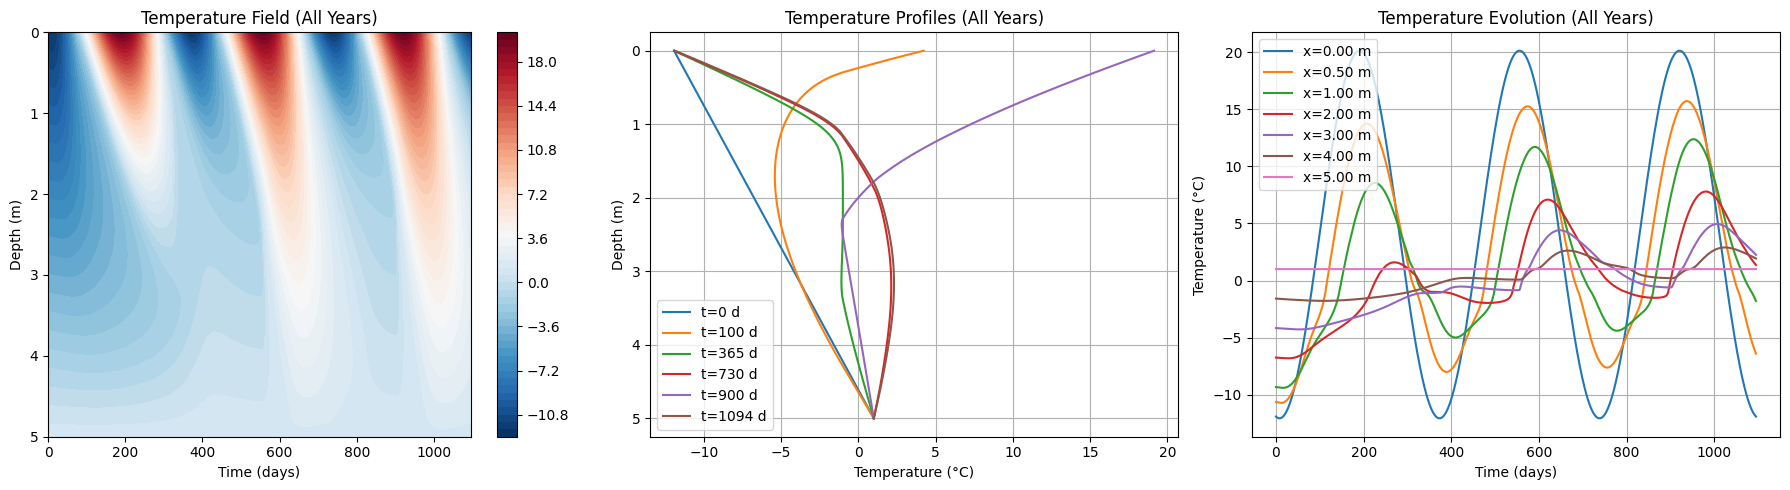

In [6]:
if __name__ == "__main__":
    params = {
        'L': 334,
        'C_i': 1.672,
        'C_l': 4.18,
        'lambda_i': 2.210e-6 * 8.64e4,
        'lambda_l': 0.465e-6 * 8.64e4,
        'lambda_f': 2e-6 * 8.64e4,
        'C_f': 1.6,
        'eta': 0.4,
        'b': 0.7,

        # smoother freezing transition
        'T_nabla': -1.0,
        'k_phi': 0.8,
        'eps_phi': 1e-6
    }

    model = FreezingSoilFDM(params)

    # 3-year simulation
    model.initialize(Nx=101, Nt=15000, Lx=5.0, T_total=365.0 * 3)

    T_field = model.solve_implicit(verbose=True)

    model.save_results("fdm_results_3years_apparent_heat_capacity.npz")
    model.save_last_year_results("fdm_results_last_year_apparent_heat_capacity.npz")

    print("All-years T min =", np.min(T_field))
    print("All-years T max =", np.max(T_field))
    print("Surface final T =", T_field[0, -1])
    print("Bottom final T =", T_field[-1, -1])

    # plot all 3 years
    model.plot_results()